In [1]:
NZ=2396; NX=13601; H=1.25

velmin=1065
velmax=4700

#chosen
fpeak=4

#consequently
h=int(velmin/fpeak/2.5/5)
nz=int(NZ*H/h)+1
nx=int(NX*H/h)+1

print('h,nz,nx=',h,nz,nx)

dt=0.6*h/velmax *0.98
T=5 #time window [s]
nt=int(T/dt)
print('dt,nt=',dt,nt)

dt=0.0026
nt=int(T/dt)
print('adjusted dt,nt=',dt,nt)

ntr=670

h,nz,nx= 21 143 810
dt,nt= 0.0026272340425531914 1903
adjusted dt,nt= 0.0026 1923


In [2]:
import os
import numpy as np
from scipy.signal import hilbert
import matplotlib.pyplot as plt

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

def write(filename,data,n=(nx,nz)):
    data.T.astype('float32').tofile(filename)

    
def hilb(data,axis=0):
    return np.imag(hilbert(data,axis=axis))

    
def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/FWD',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"mpirun -np {np} --oversubscribe {app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > $out
        
def run_remote(app='../../exe/FWD',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"mpirun -np {np} --oversubscribe {app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        #!./run.sh
        print("bash ./run.sh")
    else:
        #!./run.sh > $out
        print(f"bash ./run.sh > {out}")

## Prepare

In [3]:
##code
#!(cd ../../ ; git pull ; git checkout teaching ; make prepare)
#!(cd ../../FWD ; make cleanall ; make)
#!(cd ../../FWI ; make cleanall ; make)
#!gfortran smoothgauss2dfast_zhou.f90 -o smoothgauss2dfast_zhou

In [3]:
# #clone model
# # !wget https://s3.amazonaws.com/open.source.geoscience/open_data/elastic-marmousi/elastic-marmousi-model.tar.gz #https://wiki.seg.org/wiki/AGL_Elastic_Marmousi
# # !tar -xvzf elastic-marmousi-model.tar.gz
# # !(cd ./elastic-marmousi-model/model/ ; for fi in `ls *.tar.gz`; do tar -xvzf $$fi; done)
!segyread tape=/home/g202321550/Mycodes/SeisJIMU_VisAC_git_manage/SeisJIMU/Demo/11_Marmousi-runFWI/elastic-marmousi-model/model/MODEL_P-WAVE_VELOCITY_1.25m.segy | sugain bias=0 | sustrip > vp.bin
!segyread tape=/home/g202321550/Mycodes/SeisJIMU_VisAC_git_manage/SeisJIMU/Demo/11_Marmousi-runFWI/elastic-marmousi-model/model/MODEL_DENSITY_1.25m.segy | sustrip | farith op=scale scale=1000 > rho.bin  #convert to [kg/m3]

# !unif2 ninf=1 nz=281 nx=1361 v00=2000 > vp.bin
# !makevel nx=13601 nz=2801 dx=10 dz=10 v000=4000 > vp.bin
# !makevel nx=13601 nz=2801 dx=10 dz=10 v000=1 > rho.bin

3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00119613 s, 2.7 MB/s
n1=2801 n2=13601 d1=0.001250
nt=2801 ntr=13601 dt=0.001250
ns=2801
3200+0 records in
6+1 records out
3200 bytes (3.2 kB, 3.1 KiB) copied, 0.00115216 s, 2.8 MB/s
n1=2801 n2=13601 d1=0.001250
nt=2801 ntr=13601 dt=0.001250
ns=2801


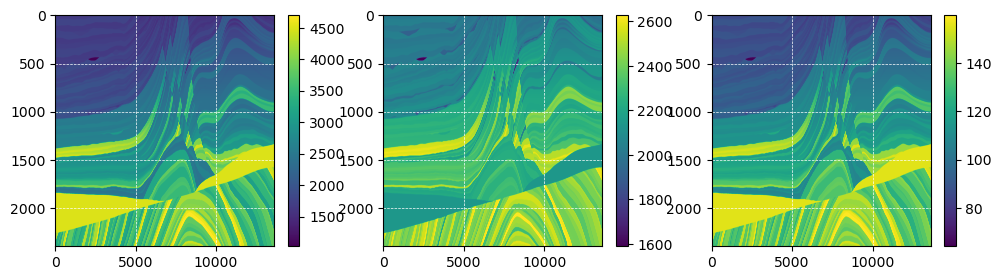

In [4]:
#chop the water layer
vp = read('vp.bin',(13601,2801)) [405:,:]
rho= read('rho.bin',(13601,2801))[405:,:]

#make Qp model by empirical law
qp = vp**0.5 #leads to a range of ~35--65, small enough to cause instability
# qp = vp**0.75 #leads to a range of ~200--550, not yet instability
qp = vp**0.6 #65-160
# qp = vp**0.55 #40-110

#plot
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(vp)
plt.subplot(1,3,2); imshow(rho)
plt.subplot(1,3,3); imshow(qp)

In [5]:
print(vp.shape)
print(qp.min())
print(qp.max())

(2396, 13601)
64.149895
159.68304


In [6]:
#save to disk
write('vpt.bin',vp)
write('rhot.bin',rho)
write('qpt.bin',qp)

In [9]:
#downsample true models
!make -B true

#make init models
!make -B init

#catenate
str=f'cat vpt.{h}m   rhot.{h}m   qpt.{h}m  > true'
!$str
!cat vpt.init  rhot.init  qpt.init > init

echo 20.1680
20.1680
./smoothgauss2dfast_zhou < par
 Input / Output file names (name_in name_out)
 Grid dimensions (n1 n2)
 Grid interval (d1 d2)
 Standard deviation of the Gaussian function (sig1, sig2)
 Wavenumbers (without factor 2*pi) higher than 0.48/sig will be suppressed
 c'est à dire que les nombres d'onde qui sont plus large que 0.48/sig ont l'amplitude sous 1% du crête. 
 Smooth parameter (0) or its inverse (1) or its inverse square (2)
 Constant topography (>=0) or variant (<0)
  go to the square inverse
  grids points involved il2 il1 =           65          65
  go back from the square inverse
   9.28382976E+10
unisam2 < vpt.smth > vpt.21m \
  nx1=2396  dx1=1.25    nx2=13601  dx2=1.25 \
  n1=143    d1=21      n2=810   d2=21
echo 20.1680
20.1680
./smoothgauss2dfast_zhou < par
 Input / Output file names (name_in name_out)
 Grid dimensions (n1 n2)
 Grid interval (d1 d2)
 Standard deviation of the Gaussian function (sig1, sig2)
 Wavenumbers (without factor 2*pi) higher than 0.

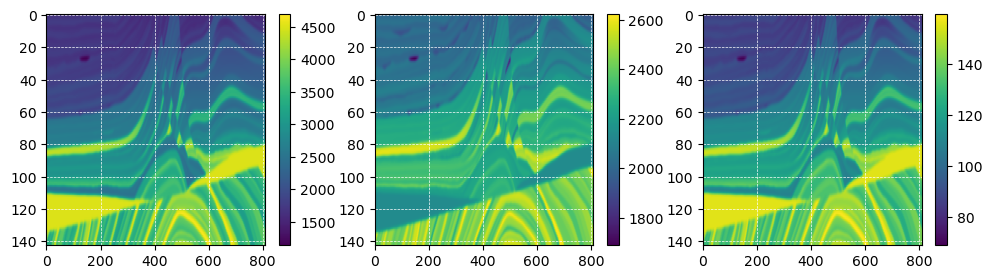

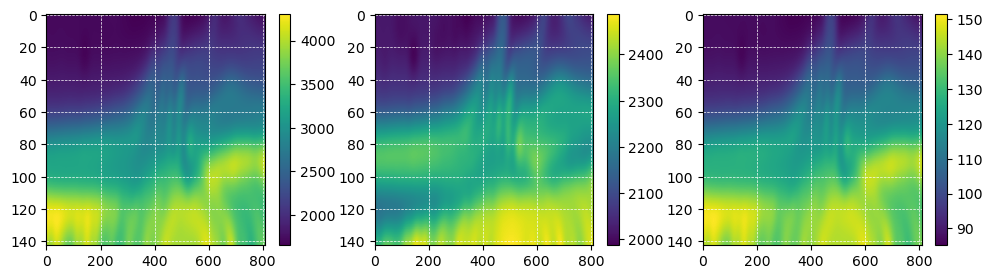

In [17]:
#plot

plt.figure(figsize=(12,3))

true=read('true',(3*nx,nz))
plt.subplot(1,3,1); imshow(true[:,:nx])
plt.subplot(1,3,2); imshow(true[:,nx:2*nx])
plt.subplot(1,3,3); imshow(true[:,2*nx:])

plt.figure(figsize=(12,3))

init=read('init',(3*nx,nz))
plt.subplot(1,3,1); imshow(init[:,:nx])
plt.subplot(1,3,2); imshow(init[:,nx:2*nx])
plt.subplot(1,3,3); imshow(init[:,2*nx:])


In [18]:
#min max of true vp
print(true[:,:nx].min(),true[:,:nx].max())
print(init[:,2*nx:].min())

1142.8925 4691.6123
85.1769


In [19]:
!cat setup_default

MODEL_SIZE              '143 810  1'
MODEL_SPACING           '21  21   1'
FILE_MODEL              'true'
MODEL_ATTRIBUTES        'vp rho qp'
MODEL_ATTRIBUTES_WRITE   vp
#FILE_TOPO              'topo'

IS_FREESURFACE          F

ACQUI_GEOMETRY          spread
FS                      '  0   1200  0'
#DS			'  0   100   0'
#NS			 144
DS			'  0   400  0'
NS			 36
FR                      '  0   0   0'
DR                      '  0   25  0'
NR                       670

SCOMP                   dpdz
RCOMP                   dpdz #'p vz'
IF_MUST_USE_RCOMP       T

WAVELET_TYPE	ricker

FPEAK        4
NT           1923
DT           0.0026

#SNAPSHOT      p
#NSNAPSHOT    50

#############
## for FWI ##
#############
FILE_DATA_PREFIX    './results_obs/Ru_Shot'
WEIGHTING           'none'

UPDATE_WAVELET	no

PARAMETER           'vp:1065:4700'

SMOOTHING     'none'
#PRECO         'z^0'

JOB             gradient

MAX_ITERATE     120
MAX_MODELING    150


IF_USE_CHECKPOINT   F


## Observed data

In [95]:
!cp setup_default setup
# !rm -r ./
!echo "DIR_OUT            results_obs_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "NS                 1 " >> setup  #Number of Shots
!echo "SNAPSHOT      p"  >> setup
# !echo "SCOMP                   dpdz"  >> setup
# !echo "IF_BLOOM       F" >> setup
# !echo "NT           3000"  >> setup
run()

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q200
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 21 Nov 11 19:13 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: 94a1283
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/11/2025
System time: 19:13:09
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_noQ
 Output directory:results_obs_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL =

In [96]:
!cp setup_default setup
# !rm -r ./
!echo "DIR_OUT            results_obs_noQ_free_surface " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "NS                 1 " >> setup  #Number of Shots
!echo "SNAPSHOT      p"  >> setup
!echo "IS_FREESURFACE          T"  >> setup
# !echo "SCOMP                   dpdz"  >> setup
# !echo "IF_BLOOM       F" >> setup
# !echo "NT           3000"  >> setup
run()

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q200
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 21 Nov 11 19:13 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: 94a1283
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/11/2025
System time: 19:13:19
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_noQ_free_surface
 Output directory:results_obs_noQ_free_surface/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartes

In [107]:
!cp setup_default setup
!echo "DIR_OUT          results_obs " >> setup
!echo "NS               1 " >> setup  #Number of Shots
!echo "SNAPSHOT      p"  >> setup
!echo "IS_FREESURFACE          T"  >> setup
#!echo "SNAPSHOT         p" >> setup
# !echo "IF_BLOOM       F" >> setup
# !echo "NT           3000"  >> setup
run()

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q200
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 21 Nov 11 19:18 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: 94a1283
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/11/2025
System time: 19:18:38
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef|

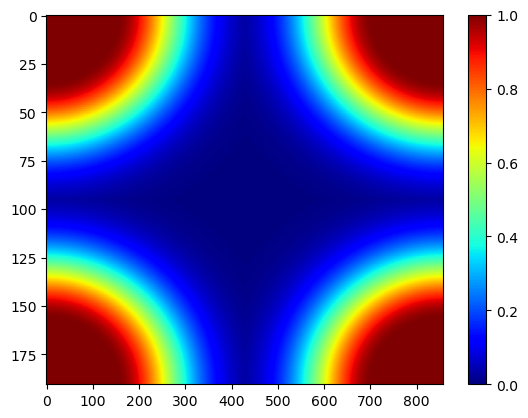

In [108]:
mask = np.fromfile('mask.bin', dtype=np.float32)  # or np.float64 if Fortran uses double
mask = mask.reshape((-1,191)).T
plt.figure()
plt.imshow(mask,cmap='jet',aspect='auto',vmin=0,vmax=1)
plt.colorbar()

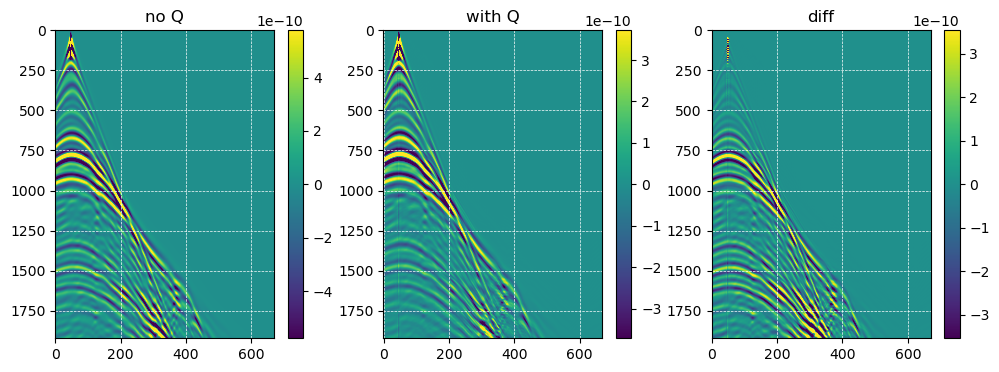

In [109]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs_noQ_free_surface/Ru_Shot0001.su'),perc=98,title='no Q')
plt.subplot(1,3,2); imshow(read_su('results_obs/Ru_Shot0001.su'    ),perc=98,title='with Q')
plt.subplot(1,3,3); imshow(read_su('results_obs_noQ_free_surface/Ru_Shot0001.su')-read_su('results_obs/Ru_Shot0001.su'),perc=98,title='diff')

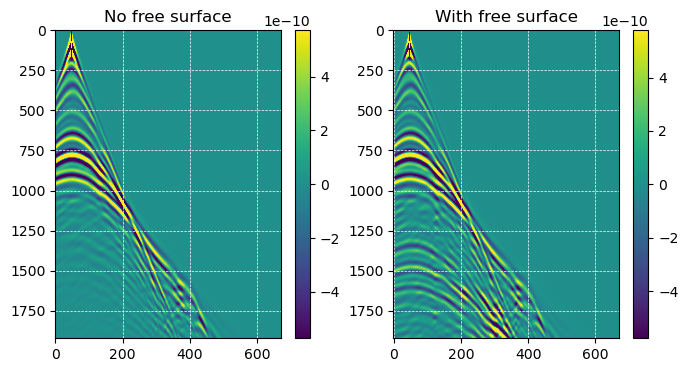

In [100]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); imshow(read_su('results_obs_noQ/Ru_Shot0001.su'),perc=98,title='No free surface')
plt.subplot(1,2,2); imshow(read_su('results_obs_noQ_free_surface/Ru_Shot0001.su'    ),perc=98,title='With free surface')

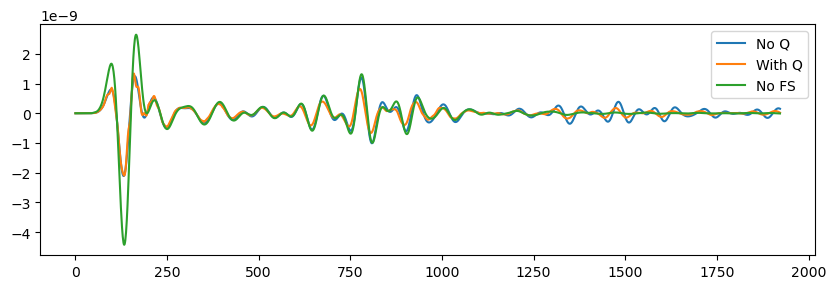

In [115]:
plt.figure(figsize=(10,3))
plt.plot(read_su('results_obs_noQ_free_surface/Ru_Shot0001.su')[:,40])
plt.plot(read_su('results_obs/Ru_Shot0001.su'    )[:,40])
plt.plot(read_su('results_obs_noQ/Ru_Shot0001.su'    )[:,40])
plt.legend(['No Q','With Q','No FS'])

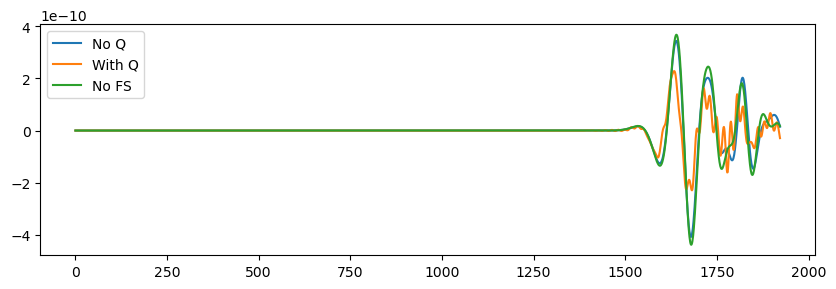

In [116]:
plt.figure(figsize=(10,3))
plt.plot(read_su('results_obs_noQ_free_surface/Ru_Shot0001.su')[:,400])
plt.plot(read_su('results_obs/Ru_Shot0001.su'    )[:,400])
plt.plot(read_su('results_obs_noQ/Ru_Shot0001.su'    )[:,400])
plt.legend(['No Q','With Q','No FS'])

## FWI gradient

In [117]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT            results_grad_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "SNAPSHOT      p"  >> setup
run(app='../../exe/FWI')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q200
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 51 Nov 11 19:27 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: 94a1283
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/11/2025
System time: 19:28:26
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad_noQ
 Output directory:results_grad_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method


In [118]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT          results_grad " >> setup
run(app='../../exe/FWI')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q200
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 51 Nov 11 19:27 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: 94a1283
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/11/2025
System time: 19:28:42
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad
 Output directory:results_grad/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesia

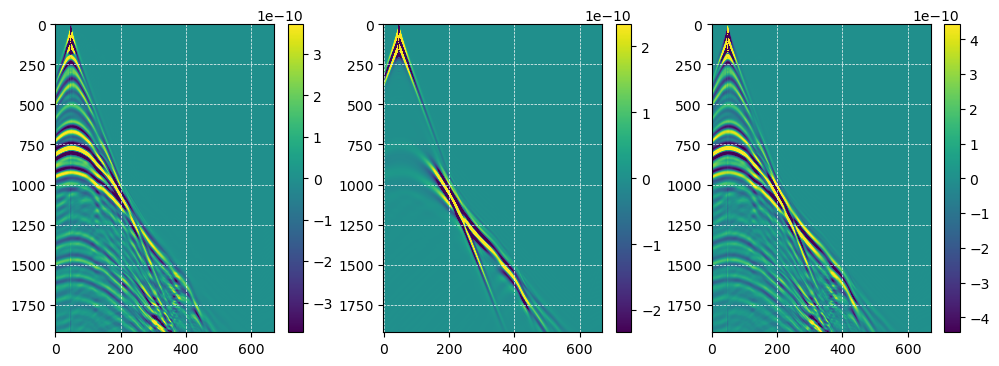

In [119]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); imshow(read_su('results_obs/Ru_Shot0001.su' ),perc=98)
plt.subplot(1,3,2); imshow(read_su('results_grad/Ru_Shot0001.su'),perc=98)
plt.subplot(1,3,3); imshow(read_su('results_grad/dadj_Shot0001.su'),perc=98)

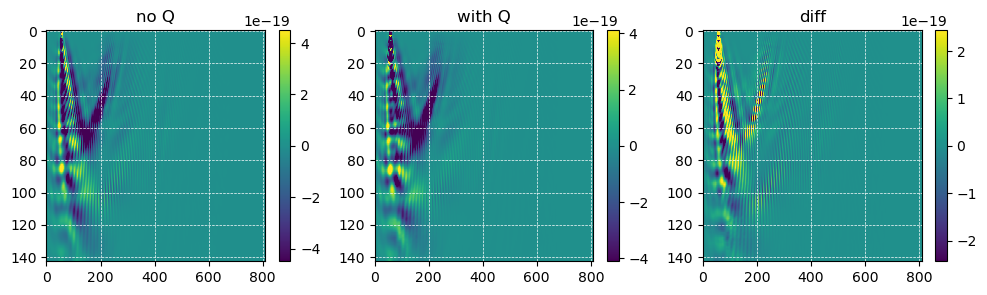

In [120]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('results_grad_noQ/qp0%pg'),perc=98,title='no Q')
plt.subplot(1,3,2); imshow(read('results_grad/qp0%pg'    ),perc=98,title='with Q')
plt.subplot(1,3,3); imshow(read('results_grad_noQ/qp0%pg')-read('results_grad/qp0%pg'),perc=98,title='diff')

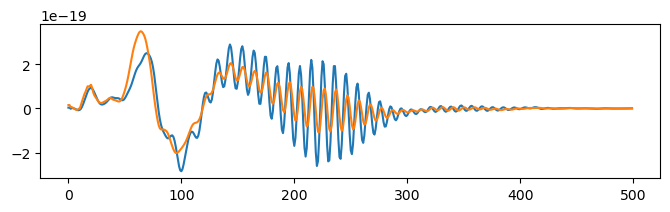

In [121]:
plt.figure(figsize=(8,2))
plt.plot(read('results_grad_noQ/qp0%pg')[100,:500],label='no Q')
plt.plot(read('results_grad/qp0%pg'    )[100,:500],label='with Q')

## Multiple shots

### data

In [132]:
!cp setup_default setup
!rm -r results_obs_noQ/
!echo "DIR_OUT            results_obs_noQ " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
# run_remote(np=36,nthreads=1,out='out')
run(np=36,nthreads=1,out='out')

In [133]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q200
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 21 Nov 11 19:45 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: 94a1283
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/11/2025
System time: 19:45:35
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs_noQ
 Output directory:results_obs_noQ/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL =

In [134]:
!cp setup_default setup
!echo "DIR_OUT          results_obs " >> setup
# run_remote(np=36,nthreads=1,out='out')
run(np=36,nthreads=1,out='out')

In [135]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q200
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 21 Nov 11 19:45 ../../exe/FWD -> fwd_VisAC2nd_FDSG_O4_
 Git Commit: 94a1283
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/11/2025
System time: 19:46:27
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef|

### gradient

In [145]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT            results_grad_noQ_FS " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "IS_FREESURFACE          T"  >> setup
# run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')
run(app='../../exe/FWI',np=36,nthreads=1,out='out')
#~3min for one gradient

Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
ERROR STOP 

Error termination. Backtrace:
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
ERROR STOP 

Error termination. Backtrace:
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
ERROR STOP 

Error termination. Backtrace:
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
ERROR STOP 

Error termination. Backtrace:
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
ERROR STOP 

Error termination. Backtrace:
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
ERROR STOP 

Error terminat

In [146]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q200
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 51 Nov 11 19:45 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: 94a1283
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/11/2025
System time: 19:57:51
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad_noQ_FS
 Output directory:results_grad_noQ_FS/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) m

In [147]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT            results_grad_noQ_noFS " >> setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "IS_FREESURFACE          F"  >> setup
# run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')
run(app='../../exe/FWI',np=36,nthreads=1,out='out')

Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_UNDERFLOW_FLAG
Note: The following floating-point excep

In [148]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q200
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 51 Nov 11 19:45 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: 94a1283
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/11/2025
System time: 20:00:22
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad_noQ_noFS
 Output directory:results_grad_noQ_noFS/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDS

In [149]:
!cp setup_default setup
!echo "FILE_MODEL         init" >> setup
!echo "DIR_OUT          results_grad " >> setup
!echo "SMOOTHING        Laplacian "  >> setup
!echo "LAP_FRAC       '0.5 0.5 0.5' "  >> setup
!echo "PRECO            z^1.5       "  >> setup
!echo "IS_FREESURFACE          T"  >> setup
# run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')
run(app='../../exe/FWI',np=36,nthreads=1,out='out')

Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floating-point exceptions are signalling: IEEE_INVALID_FLAG IEEE_DIVIDE_BY_ZERO IEEE_OVERFLOW_FLAG IEEE_UNDERFLOW_FLAG
Note: The following floatin

In [150]:
!cat out

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:          36
  Max number of OMP threads / processor:           1
 Working directory: (pwd)
/home/g202321550/Mycodes/SeisJIMU_onebranch_VisAC/SeisJIMU/Demo/11_Marmousi-runFWI_Q200
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 g202321550 g202321550 51 Nov 11 19:45 ../../exe/FWI -> fwi_VisAC2nd_FDSG_O4_velocities-density_Wolfe_lBFGS
 Git Commit: 94a1283
 Git Branch: VisAC_ZFL_WZ
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 11/11/2025
System time: 20:02:49
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI        
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_grad
 Output directory:results_grad/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D/3D VIScoACoustic propagation
2nd-order Pressure formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesia

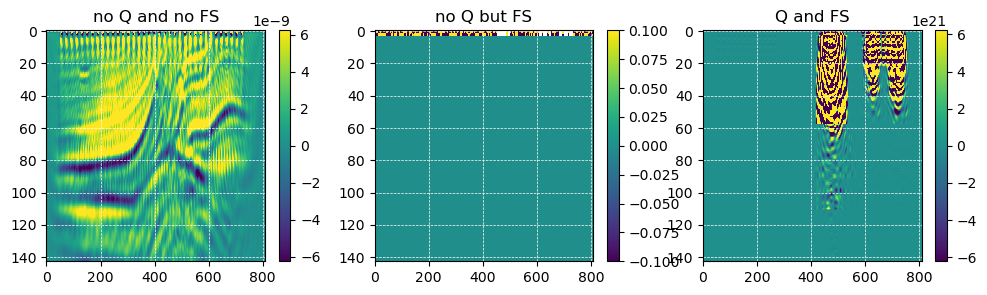

In [152]:
grad0=read('results_grad_noQ_noFS/correlate_gradient',(2*nx,nz)) [:,nx:]
grad1=read('results_grad_noQ_FS/correlate_gradient',(2*nx,nz)) [:,nx:]
grad2=read('results_grad/correlate_gradient'    ,(2*nx,nz)) [:,nx:]

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(grad0,perc=90,title='no Q and no FS')
plt.subplot(1,3,2); imshow(grad1,perc=90,title='no Q but FS')
plt.subplot(1,3,3); imshow(grad2,perc=90,title='Q and FS')
# plt.subplot(1,3,3); imshow(grad0-grad1,perc=90,title='diff')

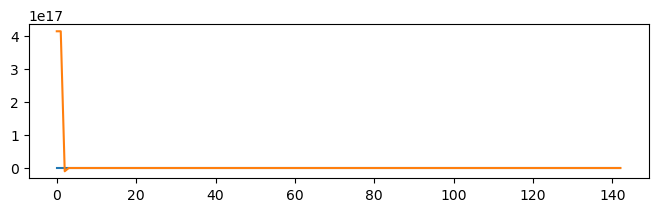

In [153]:
plt.figure(figsize=(8,2))
plt.plot(grad0[:,200],label='no Q and no FS')
plt.plot(grad1[:,200],label='no Q but FS')

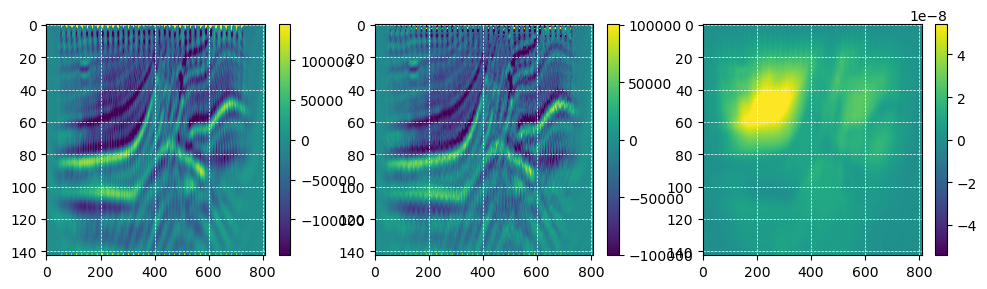

In [308]:
grad2=read('results_grad/qp0%pg')

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(grad0,perc=98)
plt.subplot(1,3,2); imshow(grad1,perc=98)
plt.subplot(1,3,3); imshow(grad2,perc=98)

## FWI NOsmth NOzpow

In [309]:
# !cp setup_default setup
# !echo "FILE_MODEL       init" >> setup
# !echo "DIR_OUT          res_NOsmth_NOzpow " >> setup
# !echo "PRECO            none         "  >> setup
# !echo "JOB              optimization " >> setup
# # run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')
# run(app='../../exe/FWI',np=36,nthreads=1,out='out')

In [310]:
# plt.figure(figsize=(12,3))
# imshow(read('res_NOsmth_NOzpow/qp0%pg'),perc=98)

In [311]:
# !cat res_NOsmth_NOzpow/optimization.log

In [312]:
# plt.figure(figsize=(12,3))
# plt.subplot(1,3,1); imshow(read('res_NOsmth_NOzpow/model_Iter1'))
# plt.subplot(1,3,2); imshow(read('res_NOsmth_NOzpow/model_Iter5'))
# plt.subplot(1,3,3); imshow(read('res_NOsmth_NOzpow/model_Iter9'))

## FWI smthx0.2 zpow1

In [313]:
!cp setup_default setup
# !rm -r ./res_smthx0.2_zpow1
!echo "FILE_MODEL       init         " >> setup
!echo "DIR_OUT          res_smthx0.2_zpow1 " >> setup
!echo "SMTH             Laplacian "     >> setup
!echo "LAP_FRAC        '0.1 0.2 0.2' "  >> setup
!echo "PRECO            z^1.2         "  >> setup
!echo "JOB              optimization " >> setup
# run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')
run(app='../../exe/FWI',np=36,nthreads=1,out='out')

mv: cannot stat 'res_smthx0.2_zpow1/updated_wavelet.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/dsyn_Shot0001.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/RE_Shot0001.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/dsyn_Shot0019.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/RE_Shot0019.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/updated_wavelet.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/dsyn_Shot0001.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/RE_Shot0001.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/dsyn_Shot0019.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/RE_Shot0019.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/updated_wavelet.su': No such file or directory
mv: cannot stat 'res_smthx0.2_zpow1/dsyn_Shot0001.su': No such file or directory
mv: cannot stat 'res_smthx0.2_

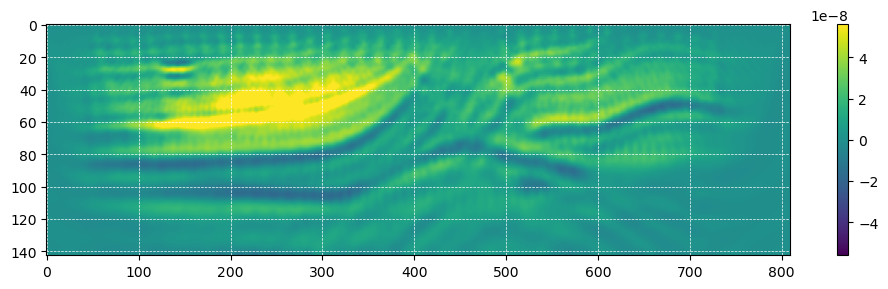

In [314]:
plt.figure(figsize=(12,3))
imshow(read('res_smthx0.2_zpow1/qp0%pg'),perc=98)

In [315]:
!cat res_smthx0.2_zpow1/optimization.log

 **********************************************************************
    LIMITED-MEMORY BFGS ALGORITHM
 **********************************************************************
     Min descent allowed      =1.0000E-08
     Max iterates allowed     =  120
     Max linesearches allowed =   12
     Max gradients allowed    =  150
     Linesearch scaler        =2.34000020E+04
     Initial gradient L1norm (║g0║₁)  =3.1866E+01
 **********************************************************************
         LinS#  Grad#     α    pert%       f                            g·d   Wolfe_cond
  Iter#         Grad#          curr%       f    f/f0(%) ║g║₁/║g0║₁(%)   g·d
     0             1                 1.3039E+01 100.000  100.000     -1.79E-02
            1      2  1.00E+00       1.2736E+01                      -1.83E-02   T F
            2      3  1.00E+01       9.9261E+00                      -1.35E-02   T T
     1             3                 9.9261E+00  76.127   84.412     -7.36E-01
 -------

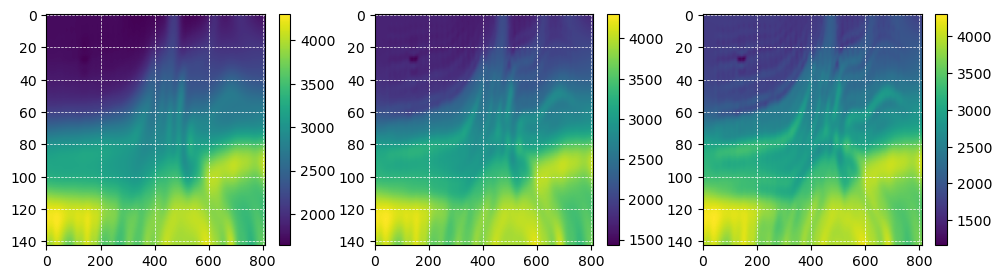

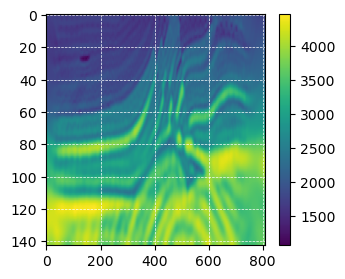

In [322]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('res_smthx0.2_zpow1/model_Iter1'))
plt.subplot(1,3,2); imshow(read('res_smthx0.2_zpow1/model_Iter4'))
plt.subplot(1,3,3); imshow(read('res_smthx0.2_zpow1/model_Iter7'))

plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('res_smthx0.2_zpow1/model_Iter31'))
# plt.subplot(1,3,2); imshow(read('res_smthx0.2_zpow1/model_final'))

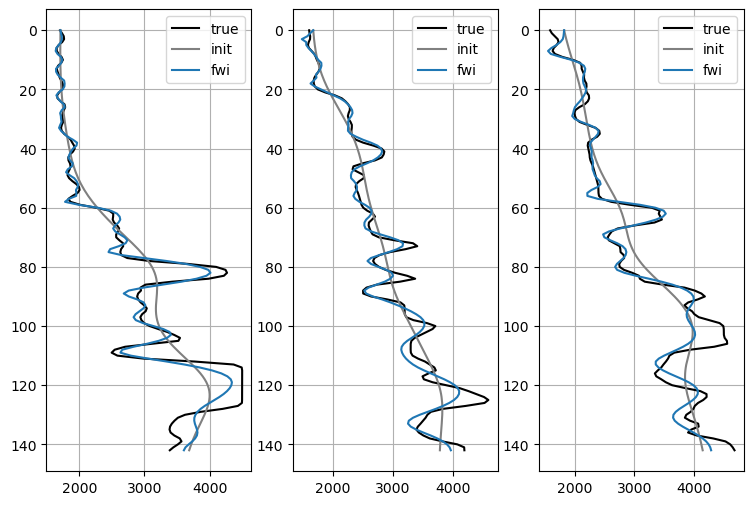

In [328]:
iz=np.arange(nz)

# fwi1=read('res_smthx0.2_zpow1/model_final')
fwi1=read('res_smthx0.2_zpow1/model_Iter32')

plt.figure(figsize=(9,6))

plt.subplot(1,3,1); ix=200
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,2); ix=400
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,3); ix=600
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1[:,ix],iz,label='fwi')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()

## FWI noQ smthx0.2 zpow1

In [318]:
!cp setup_default setup
!echo "IS_Q_ATTENUATION   F" >> setup
!echo "FILE_MODEL       init         " >> setup
!echo "DIR_OUT          res_noQ_smthx0.2_zpow1 " >> setup
!echo "SMTH             Laplacian "     >> setup
!echo "LAP_FRAC        '0.1 0.2 0.2' "  >> setup
!echo "PRECO            z^1          "  >> setup
!echo "JOB              optimization " >> setup
# run_remote(app='../../exe/FWI',np=36,nthreads=1,out='out')
run(app='../../exe/FWI',np=36,nthreads=1,out='out')

mv: cannot stat 'res_noQ_smthx0.2_zpow1/updated_wavelet.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/dsyn_Shot0001.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/RE_Shot0001.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/dsyn_Shot0019.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/RE_Shot0019.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/updated_wavelet.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/dsyn_Shot0001.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/RE_Shot0001.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/dsyn_Shot0019.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/RE_Shot0019.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/updated_wavelet.su': No such file or directory
mv: cannot stat 'res_noQ_smthx0.2_zpow1/dsyn_Shot0001.su': No such 

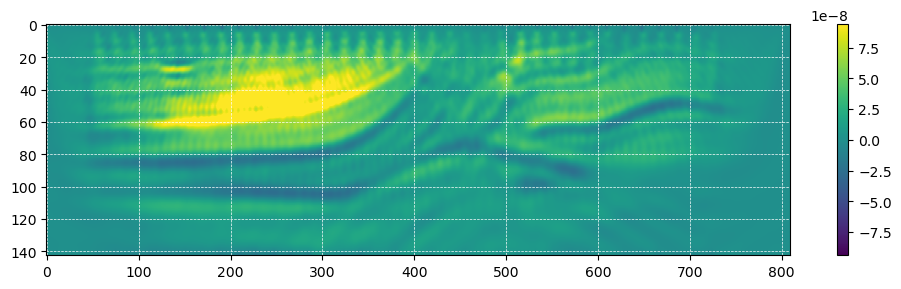

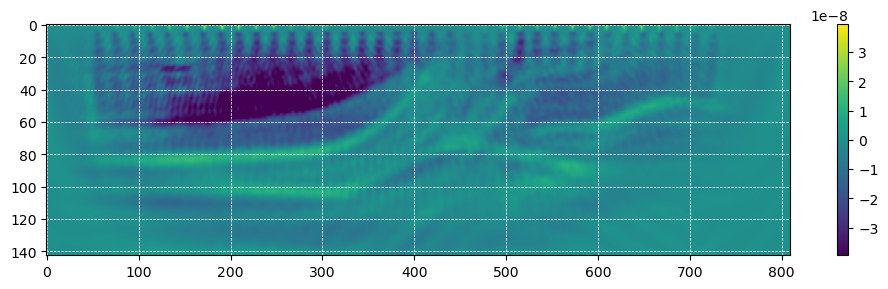

In [319]:
plt.figure(figsize=(12,3))
imshow(read('res_noQ_smthx0.2_zpow1/qp0%pg'),perc=98)

plt.figure(figsize=(12,3))
imshow(read('res_smthx0.2_zpow1/qp0%pg')-read('res_noQ_smthx0.2_zpow1/qp0%pg'),perc=98)

In [320]:
!cat res_noQ_smthx0.2_zpow1/optimization.log

 **********************************************************************
    LIMITED-MEMORY BFGS ALGORITHM
 **********************************************************************
     Min descent allowed      =1.0000E-08
     Max iterates allowed     =  120
     Max linesearches allowed =   12
     Max gradients allowed    =  150
     Linesearch scaler        =1.37586826E+04
     Initial gradient L1norm (║g0║₁)  =3.1867E+01
 **********************************************************************
         LinS#  Grad#     α    pert%       f                            g·d   Wolfe_cond
  Iter#         Grad#          curr%       f    f/f0(%) ║g║₁/║g0║₁(%)   g·d
     0             1                 1.3810E+01 100.000  100.000     -1.94E-02
            1      2  1.00E+00       1.3401E+01                      -1.96E-02   T F
            2      3  1.00E+01       1.0194E+01                      -1.14E-02   T T
     1             3                 1.0194E+01  73.814   71.305     -2.94E-01
 -------

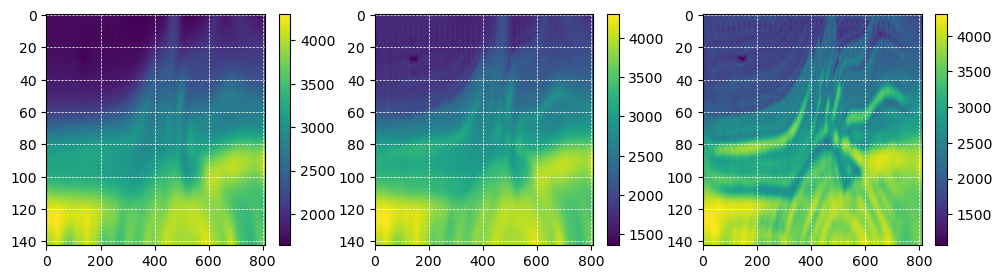

In [323]:
plt.figure(figsize=(12,3))
plt.subplot(1,3,1); imshow(read('res_noQ_smthx0.2_zpow1/model_Iter1'))
plt.subplot(1,3,2); imshow(read('res_noQ_smthx0.2_zpow1/model_Iter4'))
plt.subplot(1,3,3); imshow(read('res_noQ_smthx0.2_zpow1/model_Iter20'))

# plt.figure(figsize=(12,3))
# plt.subplot(1,3,1); imshow(read('res_noQ_smthx0.2_zpow1/model_Iter30'))
# plt.subplot(1,3,2); imshow(read('res_noQ_smthx0.2_zpow1/model_final'))
# plt.subplot(1,3,3); imshow(read('res_smthx0.2_zpow1/model_final')-read('res_noQ_smthx0.2_zpow1/model_final'))

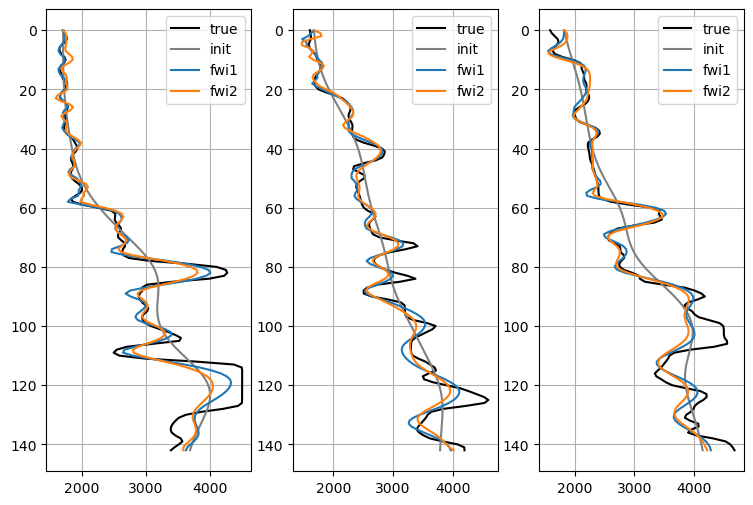

In [326]:
iz=np.arange(nz)

# fwi1=read(    'res_smthx0.2_zpow1/model_final')
# fwi2=read('res_noQ_smthx0.2_zpow1/model_final')
fwi1=read('res_smthx0.2_zpow1/model_Iter30')
fwi2=read('res_noQ_smthx0.2_zpow1/model_Iter25')

plt.figure(figsize=(9,6))

plt.subplot(1,3,1); ix=200
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1[:,ix],iz,label='fwi1')
plt.plot(fwi2[:,ix],iz,label='fwi2')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,2); ix=400
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1[:,ix],iz,label='fwi1')
plt.plot(fwi2[:,ix],iz,label='fwi2')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()

plt.subplot(1,3,3); ix=600
plt.plot(true[:,ix],iz,label='true',color='k')
plt.plot(init[:,ix],iz,label='init',color='gray')
plt.plot(fwi1[:,ix],iz,label='fwi1')
plt.plot(fwi2[:,ix],iz,label='fwi2')
plt.gca().invert_yaxis()
plt.grid(visible=True)
plt.legend()